# Group Project, Radial Velocity vs Time Analysis, Author: Trace Oettinger

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
data = np.loadtxt("C:/Users/apple/Downloads/Dataforproject.txt", skiprows=24)

time = data[:,0]
rv = data[:,1]
rv_err = data[:,2]

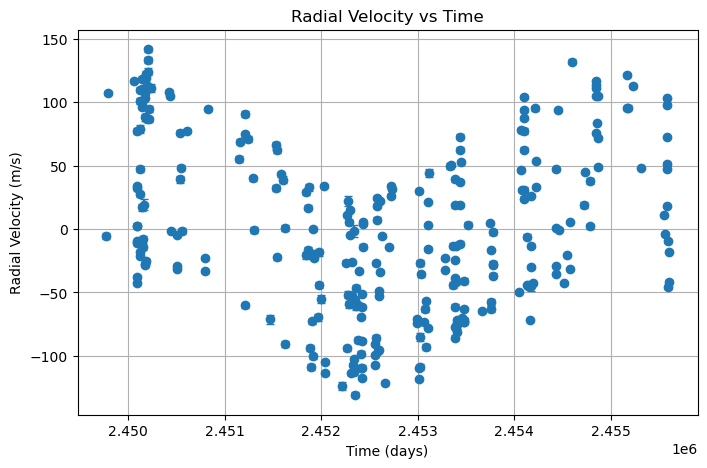

In [3]:
plt.figure(figsize=(8,5))

plt.errorbar(time, rv, yerr=rv_err, fmt='o', capsize=3)

plt.xlabel("Time (days)")
plt.ylabel("Radial Velocity (m/s)")
plt.title("Radial Velocity vs Time")

plt.grid()

plt.show()

In [4]:
def rv_model(t, K, P, phi, C):
    return K * np.sin(2*np.pi*t/P + phi) + C

params, cov = curve_fit(rv_model, time, rv)

K, P, phi, C = params

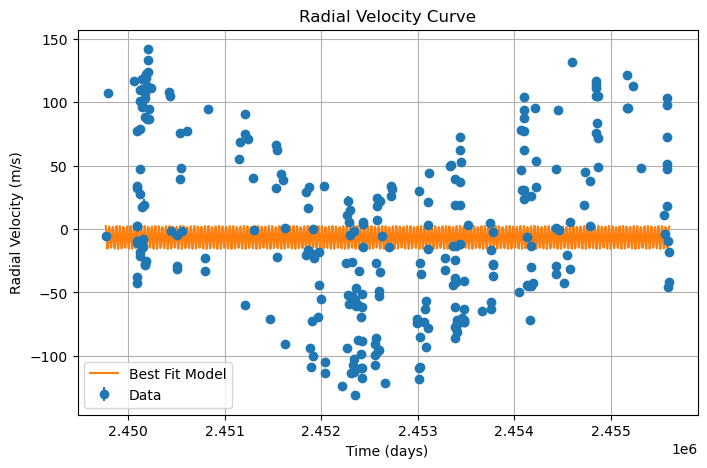

In [5]:
t_fit = np.linspace(min(time), max(time), 1000)
rv_fit = rv_model(t_fit, K, P, phi, C)

plt.figure(figsize=(8,5))

plt.errorbar(time, rv, yerr=rv_err, fmt='o', label="Data")
plt.plot(t_fit, rv_fit, label="Best Fit Model")

plt.xlabel("Time (days)")
plt.ylabel("Radial Velocity (m/s)")
plt.title("Radial Velocity Curve")

plt.legend()
plt.grid()

plt.show()

rv_model_values = rv_model(time, K, P, phi, C)

residuals = rv - rv_model_values

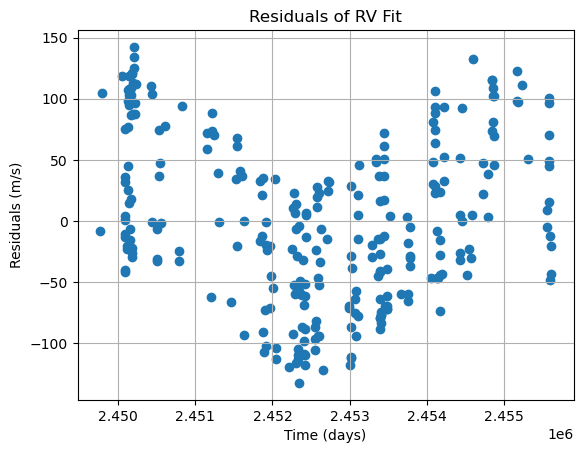

Standard deviation: 66.79556366054689


In [6]:
plt.figure()

plt.scatter(time, residuals)

plt.xlabel("Time (days)")
plt.ylabel("Residuals (m/s)")
plt.title("Residuals of RV Fit")

plt.grid()
plt.show()

std_residuals = np.std(residuals)

print("Standard deviation:", std_residuals)

In [7]:
M_star = 0.95

M_planet = (K/28.4) * (P/365)**(1/3) * (M_star)**(2/3)

print("Planet mass (Jupiter masses):", M_planet)

Planet mass (Jupiter masses): -0.04310842274784709
